In [1]:
from pynq import Overlay
from pynq import allocate
import numpy as np
import matplotlib.pyplot as plt
from pynq import DefaultIP
import IPython.display as ipd

In [2]:
ol = Overlay("design_1BandS.bit")
#ol?

In [3]:
dma = ol.axi_dma
buttons = ol.axi_gpio_0
switches = ol.axi_gpio_1

In [4]:
buttons.read(0x00)

0

In [5]:
switches.read(0x00)

0

In [6]:
input_buffer = allocate(shape=(4000,), dtype=np.uint32)
output_buffer = allocate(shape=(4000,), dtype=np.uint32)

In [7]:
for i in range(4000):
    input_buffer[i] = 1

In [8]:
dma.sendchannel.transfer(input_buffer)
dma.recvchannel.transfer(output_buffer)
dma.sendchannel.wait()
dma.recvchannel.wait()

In [9]:
input_buffer_C = allocate(shape=(4000,), dtype=np.uint32)
input_buffer_D = allocate(shape=(4000,), dtype=np.uint32)
input_buffer_E = allocate(shape=(4000,), dtype=np.uint32)
input_buffer_F = allocate(shape=(4000,), dtype=np.uint32)
input_buffer_G = allocate(shape=(4000,), dtype=np.uint32)
input_buffer_A = allocate(shape=(4000,), dtype=np.uint32)
input_buffer_B = allocate(shape=(4000,), dtype=np.uint32)
for i in range(4000):
    input_buffer_C[i] = 0
    input_buffer_D[i] = 1
    input_buffer_E[i] = 2
    input_buffer_F[i] = 3
    input_buffer_G[i] = 4
    input_buffer_A[i] = 5
    input_buffer_B[i] = 6

In [ ]:
while switches.read(0x00) == 0:
    buttonPressed = False
    combo = buttons.read(0x00)
    if combo == 1:
        dma.sendchannel.transfer(input_buffer_C)
        dma.recvchannel.transfer(output_buffer)
        dma.sendchannel.wait()
        dma.recvchannel.wait()
        buttonPressed = True
    elif combo == 2:
        dma.sendchannel.transfer(input_buffer_D)
        dma.recvchannel.transfer(output_buffer)
        dma.sendchannel.wait()
        dma.recvchannel.wait()
        buttonPressed = True
    elif combo == 3:
        dma.sendchannel.transfer(input_buffer_E)
        dma.recvchannel.transfer(output_buffer)
        dma.sendchannel.wait()
        dma.recvchannel.wait()
        buttonPressed = True
    elif combo == 4:
        dma.sendchannel.transfer(input_buffer_F)
        dma.recvchannel.transfer(output_buffer)
        dma.sendchannel.wait()
        dma.recvchannel.wait()
        buttonPressed = True
    elif combo == 5:
        dma.sendchannel.transfer(input_buffer_G)
        dma.recvchannel.transfer(output_buffer)
        dma.sendchannel.wait()
        dma.recvchannel.wait()
        buttonPressed = True
    elif combo == 6:
        dma.sendchannel.transfer(input_buffer_A)
        dma.recvchannel.transfer(output_buffer)
        dma.sendchannel.wait()
        dma.recvchannel.wait()
        buttonPressed = True
    elif combo == 8:
        dma.sendchannel.transfer(input_buffer_B)
        dma.recvchannel.transfer(output_buffer)
        dma.sendchannel.wait()
        dma.recvchannel.wait()
        buttonPressed = True
    else:
        buttonPressed = False
    
    if buttonPressed == True:
        ipd.display(ipd.Audio(output_buffer, rate = 48000, autoplay = 'true'))
    while buttons.read(0x00) != 0:
        continue
    
        
    

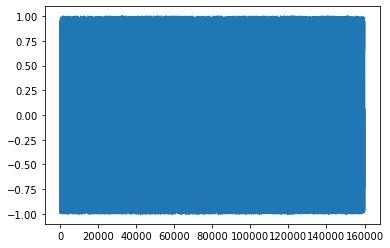

In [9]:
longAudio = []
n = 0
while n < 40:
    dma.sendchannel.transfer(input_buffer)
    dma.recvchannel.transfer(output_buffer)
    dma.sendchannel.wait()
    dma.recvchannel.wait()
    
    for i in range(4000):
        
        longAudio.append(output_buffer[(i)]/(2**31)-1)
        
    
        
    n += 1
    
ipd.display(ipd.Audio(longAudio, rate = 48000))
plt.plot(longAudio)

<function matplotlib.pyplot.show(*args, **kw)>

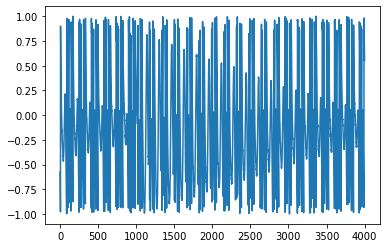

In [264]:


jgjj = []
for i in range(4000):
    jgjj.append(output_buffer[i]/(2**31)-1)
    
#print(jgjj)
plt.plot(jgjj)
plt.show

In [233]:
wave_audio = np.sin(jgjj)
ipd.display(ipd.Audio(jgjj, rate = 48000))